# HDBSCAN Clustering for Betacov sequences

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
import numpy as np
import umap
import hdbscan
from tqdm.auto import tqdm

def umap_hdbscan_parameter_sweep(embedded_df, n_neighbors_list, min_dist_list, min_samples_list, min_cluster_size_list):
    umap_grid = {
        "n_neighbors": n_neighbors_list,
        "min_dist": min_dist_list,
    }
    umap_param_list = list(ParameterGrid(umap_grid))

    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    embedding_matrix = np.vstack(embedded_df["embedding"].values)
    y_true = embedded_df["variant"].values

    # Parameter Sweep (UMAP)
    for umap_params in tqdm(umap_param_list, desc="UMAP sweep"):
        reducer = umap.UMAP(
            n_neighbors=umap_params["n_neighbors"],
            min_dist=umap_params["min_dist"],
            metric="cosine",
            random_state=42,
        )
        X_red = reducer.fit_transform(embedding_matrix)

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(
            hdbscan_param_list,
            desc=f"HDBSCAN sweep (n_neighbors={umap_params['n_neighbors']}, min_dist={umap_params['min_dist']})",
            leave=False,
        ):
            clusterer = hdbscan.HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
                core_dist_n_jobs=-1,
            ).fit(X_red)

            labels = clusterer.labels_
            ari = adjusted_rand_score(y_true, labels)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters > 1:
                silhouette_avg = silhouette_score(X_red, labels)
            else:
                silhouette_avg = np.nan

            all_results.append({
                "n_neighbors": umap_params["n_neighbors"],
                "min_dist": umap_params["min_dist"],
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": (labels == -1).mean(),
                "silhouette": silhouette_avg,
                "n_clusters": n_clusters,
            })

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

In [ ]:
%%time

curr_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/betacov"
data_dir = "/panfs/biopan03/prime_ml/prime/data/betacov"
parquet_file = os.path.join(data_dir, f"betacoronavirus_seq_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

umap_grid = {
    "n_neighbors": list(range(2,74)),
    "min_dist": np.round(np.arange(0.0, 0.51, 0.05), 2).tolist(),
}

hdbscan_grid = {
    "min_samples": range(1, 26),
    "min_cluster_size": range(2, 26),
}

full_results_df = umap_hdbscan_parameter_sweep(
    embedded_df, 
    umap_grid["n_neighbors"],
    umap_grid["min_dist"],
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_df.to_csv(os.path.join(curr_dir, "BETACOV.from-esm-mlm.CLS-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 792/792 [12:40<00:00,  1.04it/s]


CPU times: user 12min 30s, sys: 10 s, total: 12min 40s
Wall time: 12min 41s


In [14]:
# Best result within each UMAP setting, based on just ARI and SC
summary_df = (
    full_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)
display(summary_df)

print(f"Best overall UMAP + HDBSCAN settings (top 3):")
top3 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(3)
).reset_index(drop=True)
display(top3)

,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,2,0.00,5,2,0.281790,0.373333,0.254916,7
1,2,0.05,3,2,0.215141,0.066667,0.813031,14
2,2,0.10,4,8,0.270607,0.160000,0.534360,3
3,2,0.15,1,6,0.219279,0.226667,0.403734,6
4,2,0.20,5,9,0.358310,0.226667,0.465086,6
...,...,...,...,...,...,...,...,...
787,73,0.30,1,3,0.592132,0.026667,0.617910,6
788,73,0.35,1,5,0.616514,0.000000,0.653313,6
789,73,0.40,1,3,0.544448,0.013333,0.573240,7
790,73,0.45,1,3,0.536351,0.000000,0.607749,8


Best overall UMAP + HDBSCAN settings (top 3):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,8,0.5,13,2,0.935639,0.066667,0.660722,3
1,6,0.3,18,2,0.906290,0.186667,0.563793,3
2,10,0.0,5,14,0.846614,0.000000,0.672772,3


In [ ]:
# Best overall, ARI and Noise Fraction and SC
summary_df = (
    full_results_df
    .sort_values(by=["ari", "noise_fraction", "silhouette"], ascending=[False, True, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)
display(summary_df)

print(f"Best overall UMAP + HDBSCAN settings (top 3):")
top3 = (
    summary_df.sort_values(
        by=["best_ari", "best_noise_fraction", "best_silhouette"],
        ascending=[False, True, False]
    ).head(3)
).reset_index(drop=True)
display(top3)

,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,2,0.00,5,2,0.281790,0.373333,0.254916,7
1,2,0.05,3,2,0.215141,0.066667,0.813031,14
2,2,0.10,4,8,0.270607,0.160000,0.534360,3
3,2,0.15,1,6,0.219279,0.226667,0.403734,6
4,2,0.20,5,9,0.358310,0.226667,0.465086,6
...,...,...,...,...,...,...,...,...
787,73,0.30,1,3,0.592132,0.026667,0.617910,6
788,73,0.35,1,5,0.616514,0.000000,0.653313,6
789,73,0.40,1,3,0.544448,0.013333,0.573240,7
790,73,0.45,1,3,0.536351,0.000000,0.607749,8


Best overall UMAP + HDBSCAN settings (top 3):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,8,0.5,13,2,0.935639,0.066667,0.660722,3
1,6,0.3,18,2,0.906290,0.186667,0.563793,3
2,10,0.0,5,14,0.846614,0.000000,0.672772,3


---

In [18]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
import numpy as np
from openTSNE import TSNE
import hdbscan
from tqdm.auto import tqdm

def tsne_hdbscan_parameter_sweep(embedded_df, perplexity_list, min_samples_list, min_cluster_size_list):
    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    embedding_matrix = np.vstack(embedded_df["embedding"].values)
    y_true = embedded_df["variant"].values

    # Parameter Sweep (TSNE)
    for perp in tqdm(perplexity_list, desc="TSNE sweep"):
        reducer = TSNE(
            n_components=2, 
            perplexity=perp, 
            learning_rate='auto', 
            random_state=42, 
            n_jobs=8
        )
        X_red = reducer.fit(embedding_matrix)

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(
            hdbscan_param_list,
            desc=f"HDBSCAN sweep (perplexity={perp})",
            leave=False,
        ):
            clusterer = hdbscan.HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
                core_dist_n_jobs=-1,
            ).fit(X_red)

            labels = clusterer.labels_
            ari = adjusted_rand_score(y_true, labels)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters > 1:
                silhouette_avg = silhouette_score(X_red, labels)
            else:
                silhouette_avg = np.nan

            all_results.append({
                "perplexity": perp,
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": (labels == -1).mean(),
                "silhouette": silhouette_avg,
                "n_clusters": n_clusters,
            })

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

In [19]:
%%time

curr_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/betacov"
data_dir = "/panfs/biopan03/prime_ml/prime/data/betacov"
parquet_file = os.path.join(data_dir, f"betacoronavirus_seq_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

n_samples = len(embedded_df)
max_perplexity = max(2, (n_samples - 1) // 3)
perplexity_list = range(2, max_perplexity + 1)

hdbscan_grid = {
    "min_samples": range(1, 26),
    "min_cluster_size": range(2, 26),
}

full_results_df = tsne_hdbscan_parameter_sweep(
    embedded_df, 
    perplexity_list,
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_df.to_csv(os.path.join(curr_dir, "BETACOV.from-esm-mlm.CLS-tsne_hdbscan-parameter_sweep.csv"), index=False)

TSNE sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:23<00:00,  1.00s/it]

CPU times: user 3min 7s, sys: 3.82 s, total: 3min 10s
Wall time: 23.1 s


In [24]:
# Best result within each TSNE setting, based on just ARI and SC
summary_df = (
    full_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["perplexity"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)
display(summary_df)

print(f"Best overall TSNE + HDBSCAN settings (top 3):")
top3 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(3)
).reset_index(drop=True)
display(top3)

,perplexity,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,2,1,11,0.579865,0.226667,0.493541,3
1,3,1,11,0.872938,0.000000,0.596661,3
2,4,6,4,0.678568,0.066667,0.706216,5
3,5,8,2,0.667941,0.000000,0.722787,4
4,6,9,2,0.688273,0.213333,0.476435,4
5,7,4,2,0.553648,0.000000,0.780619,7
6,8,6,10,0.716317,0.053333,0.633829,4
7,9,9,2,0.674446,0.000000,0.653405,4
8,10,1,11,0.725242,0.000000,0.725532,4
9,11,4,2,0.616514,0.000000,0.783201,6


Best overall TSNE + HDBSCAN settings (top 3):


,perplexity,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,3,1,11,0.872938,0.000000,0.596661,3
1,17,6,2,0.744594,0.053333,0.639309,4
2,22,2,12,0.743053,0.320000,0.650064,3


In [25]:
# Best overall, ARI and Noise Fraction and SC
summary_df = (
    full_results_df
    .sort_values(by=["ari", "noise_fraction", "silhouette"], ascending=[False, True, False])
    .groupby(["perplexity"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)
display(summary_df)

print(f"Best overall TSNE + HDBSCAN settings (top 3):")
top3 = (
    summary_df.sort_values(
        by=["best_ari", "best_noise_fraction", "best_silhouette"],
        ascending=[False, True, False]
    ).head(3)
).reset_index(drop=True)
display(top3)

,perplexity,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,2,1,11,0.579865,0.226667,0.493541,3
1,3,1,11,0.872938,0.000000,0.596661,3
2,4,6,4,0.678568,0.066667,0.706216,5
3,5,8,2,0.667941,0.000000,0.722787,4
4,6,9,2,0.688273,0.213333,0.476435,4
5,7,4,2,0.553648,0.000000,0.780619,7
6,8,6,10,0.716317,0.053333,0.633829,4
7,9,9,2,0.674446,0.000000,0.653405,4
8,10,1,11,0.725242,0.000000,0.725532,4
9,11,4,2,0.616514,0.000000,0.783201,6


Best overall TSNE + HDBSCAN settings (top 3):


,perplexity,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,3,1,11,0.872938,0.000000,0.596661,3
1,17,6,2,0.744594,0.053333,0.639309,4
2,22,2,12,0.743053,0.320000,0.650064,3


In [275]:
def plot_hdbscan_heatmaps_from_results(full_results_df, perplexity):
    sub = full_results_df[full_results_df["perplexity"] == perplexity].copy()

    ari_matrix = sub.pivot(index="min_samples", columns="min_cluster_size", values="ari")
    silhouette_matrix = sub.pivot(index="min_samples", columns="min_cluster_size", values="silhouette")
    noise_matrix = sub.pivot(index="min_samples", columns="min_cluster_size", values="noise_fraction")

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, axs = plt.subplots(3, 1, figsize=(18, 22))

    sns.heatmap(
        ari_matrix,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="RdBu",
        ax=axs[0],
        vmin=-0.19,
        vmax=1
    )
    axs[0].set_title(f"ARI | Perplexity={perplexity}")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_samples")

    sns.heatmap(
        noise_matrix,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="RdBu_r",
        ax=axs[1],
        vmin=0,
        vmax=1
    )
    axs[1].set_title(f"Noise fraction | Perplexity={perplexity}")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_samples")

    sns.heatmap(
        silhouette_matrix,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cmap="RdBu",
        ax=axs[2],
        vmin=-0.19,
        vmax=1
    )
    axs[2].set_title(f"Silhouette | Perplexity={perplexity}")
    axs[2].set_xlabel("min_cluster_size")
    axs[2].set_ylabel("min_samples")

    plt.tight_layout()
    plt.show()

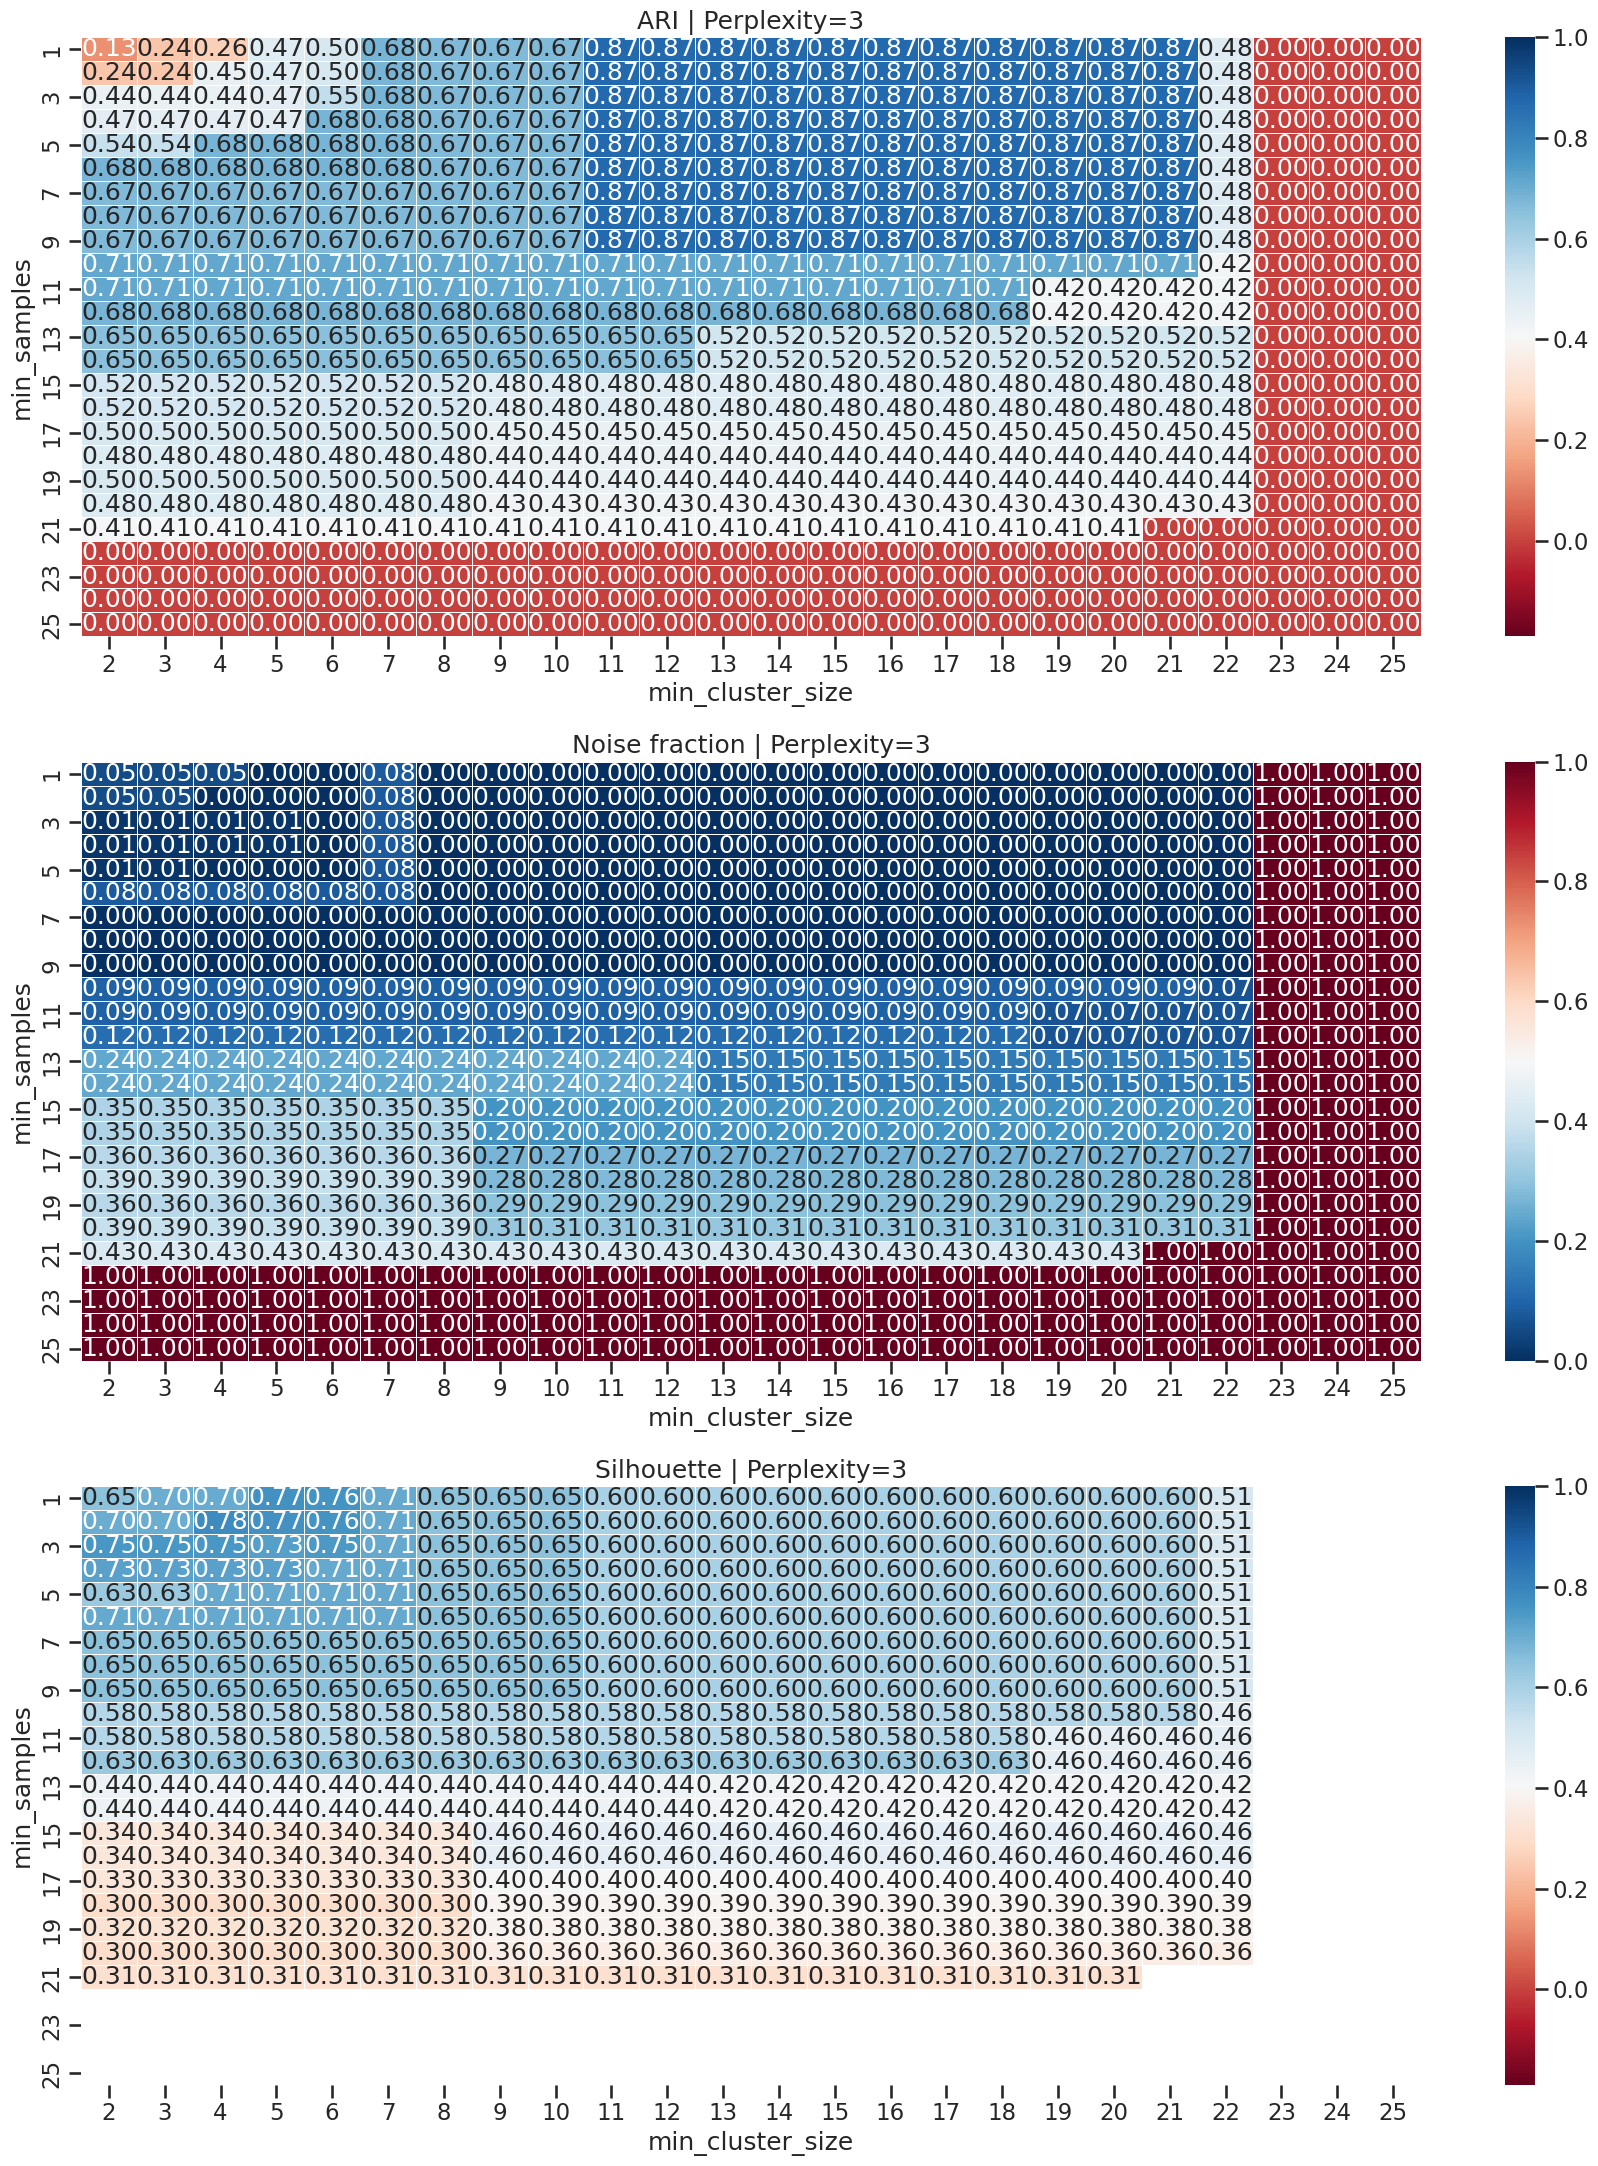

In [276]:
best_perp = int(top3_perps.iloc[0]["perplexity"])
plot_hdbscan_heatmaps_from_results(full_results_df, best_perp)

---

In [266]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from openTSNE import TSNE

def plot_top_perplexities(embedded_df, perp_list):
    n = len(perp_list)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    embedding_matrix = np.vstack(embedded_df["embedding"].values)

    unique_variants = np.unique(embedded_df["variant"])
    variant_color_palette = sns.color_palette("tab10", n_colors=len(unique_variants))
    variant_color_dict = {
        label: color for label, color in zip(unique_variants, variant_color_palette)
    }

    for ax, perp in zip(axes, perp_list):
        tsne_reducer = TSNE(
            n_components=2,
            perplexity=int(perp),
            learning_rate="auto",
            random_state=42,
            n_jobs=8
        )

        X_red = np.asarray(tsne_reducer.fit(embedding_matrix))

        plot_df = pd.DataFrame({
            "t-SNE component 1": X_red[:, 0],
            "t-SNE component 2": X_red[:, 1],
            "Variant": embedded_df["variant"].values
        })

        variant_colors = [variant_color_dict[v] for v in plot_df["Variant"]]

        ax.scatter(
            plot_df["t-SNE component 1"],
            plot_df["t-SNE component 2"],
            c=variant_colors,
            s=20,
            alpha=0.5,
            edgecolor="none",
            linewidth=0
        )
        ax.set_title(f"Perplexity={int(perp)}")

        handles = [
            plt.Line2D(
                [0], [0],
                marker="o",
                color="w",
                markerfacecolor=variant_color_dict[v],
                markersize=7
            )
            for v in unique_variants
        ]
        ax.legend(handles, unique_variants, loc="best", fontsize=8, title="Variant", title_fontsize=9)

    # Hide unused axes
    for ax in axes[len(perp_list):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

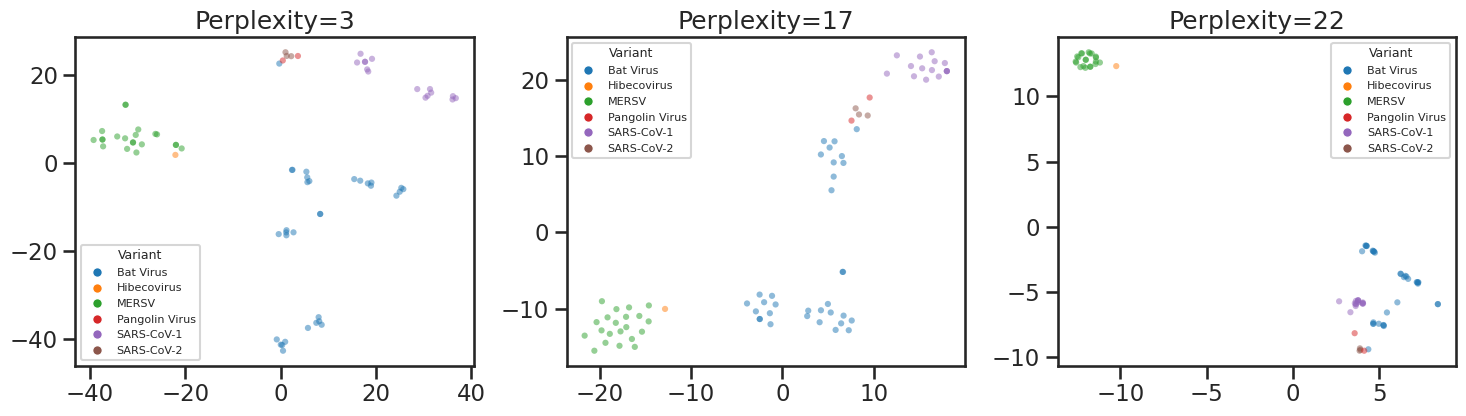

In [268]:
top3_perps = top3_perps["perplexity"].values

plot_top_perplexities(
    embedded_df, 
    top3_perps
)

Find highest or a sufficiently highest Silhouette Coefficient, Adjusted Rand Index.

min_sample 1, min_cluster_size 2: Adjusted Rand Index: 0.14, Silhouette Coefficient: 0.64
min_sample 1, min_cluster_size 3: Adjusted Rand Index: 0.24, Silhouette Coefficient: 0.69
min_sample 1, min_cluster_size 4: Adjusted Rand Index: 0.26, Silhouette Coefficient: 0.69
min_sample 1, min_cluster_size 5: Adjusted Rand Index: 0.48, Silhouette Coefficient: 0.76
min_sample 1, min_cluster_size 6: Adjusted Rand Index: 0.55, Silhouette Coefficient: 0.74
min_sample 1, min_cluster_size 7: Adjusted Rand Index: 0.55, Silhouette Coefficient: 0.74
min_sample 1, min_cluster_size 8: Adjusted Rand Index: 0.55, Silhouette Coefficient: 0.63
min_sample 1, min_cluster_size 9: Adjusted Rand Index: 0.55, Silhouette Coefficient: 0.63
min_sample 1, min_cluster_size 10: Adjusted Rand Index: 0.67, Silhouette Coefficient: 0.63
min_sample 1, min_cluster_size 11: Adjusted Rand Index: 0.87, Silhouette Coefficient: 0.61
min_sample 1, min_cluster_size 12: Adjusted Rand Index: 0.87, Silhouette Coefficient: 0.61
min_sam

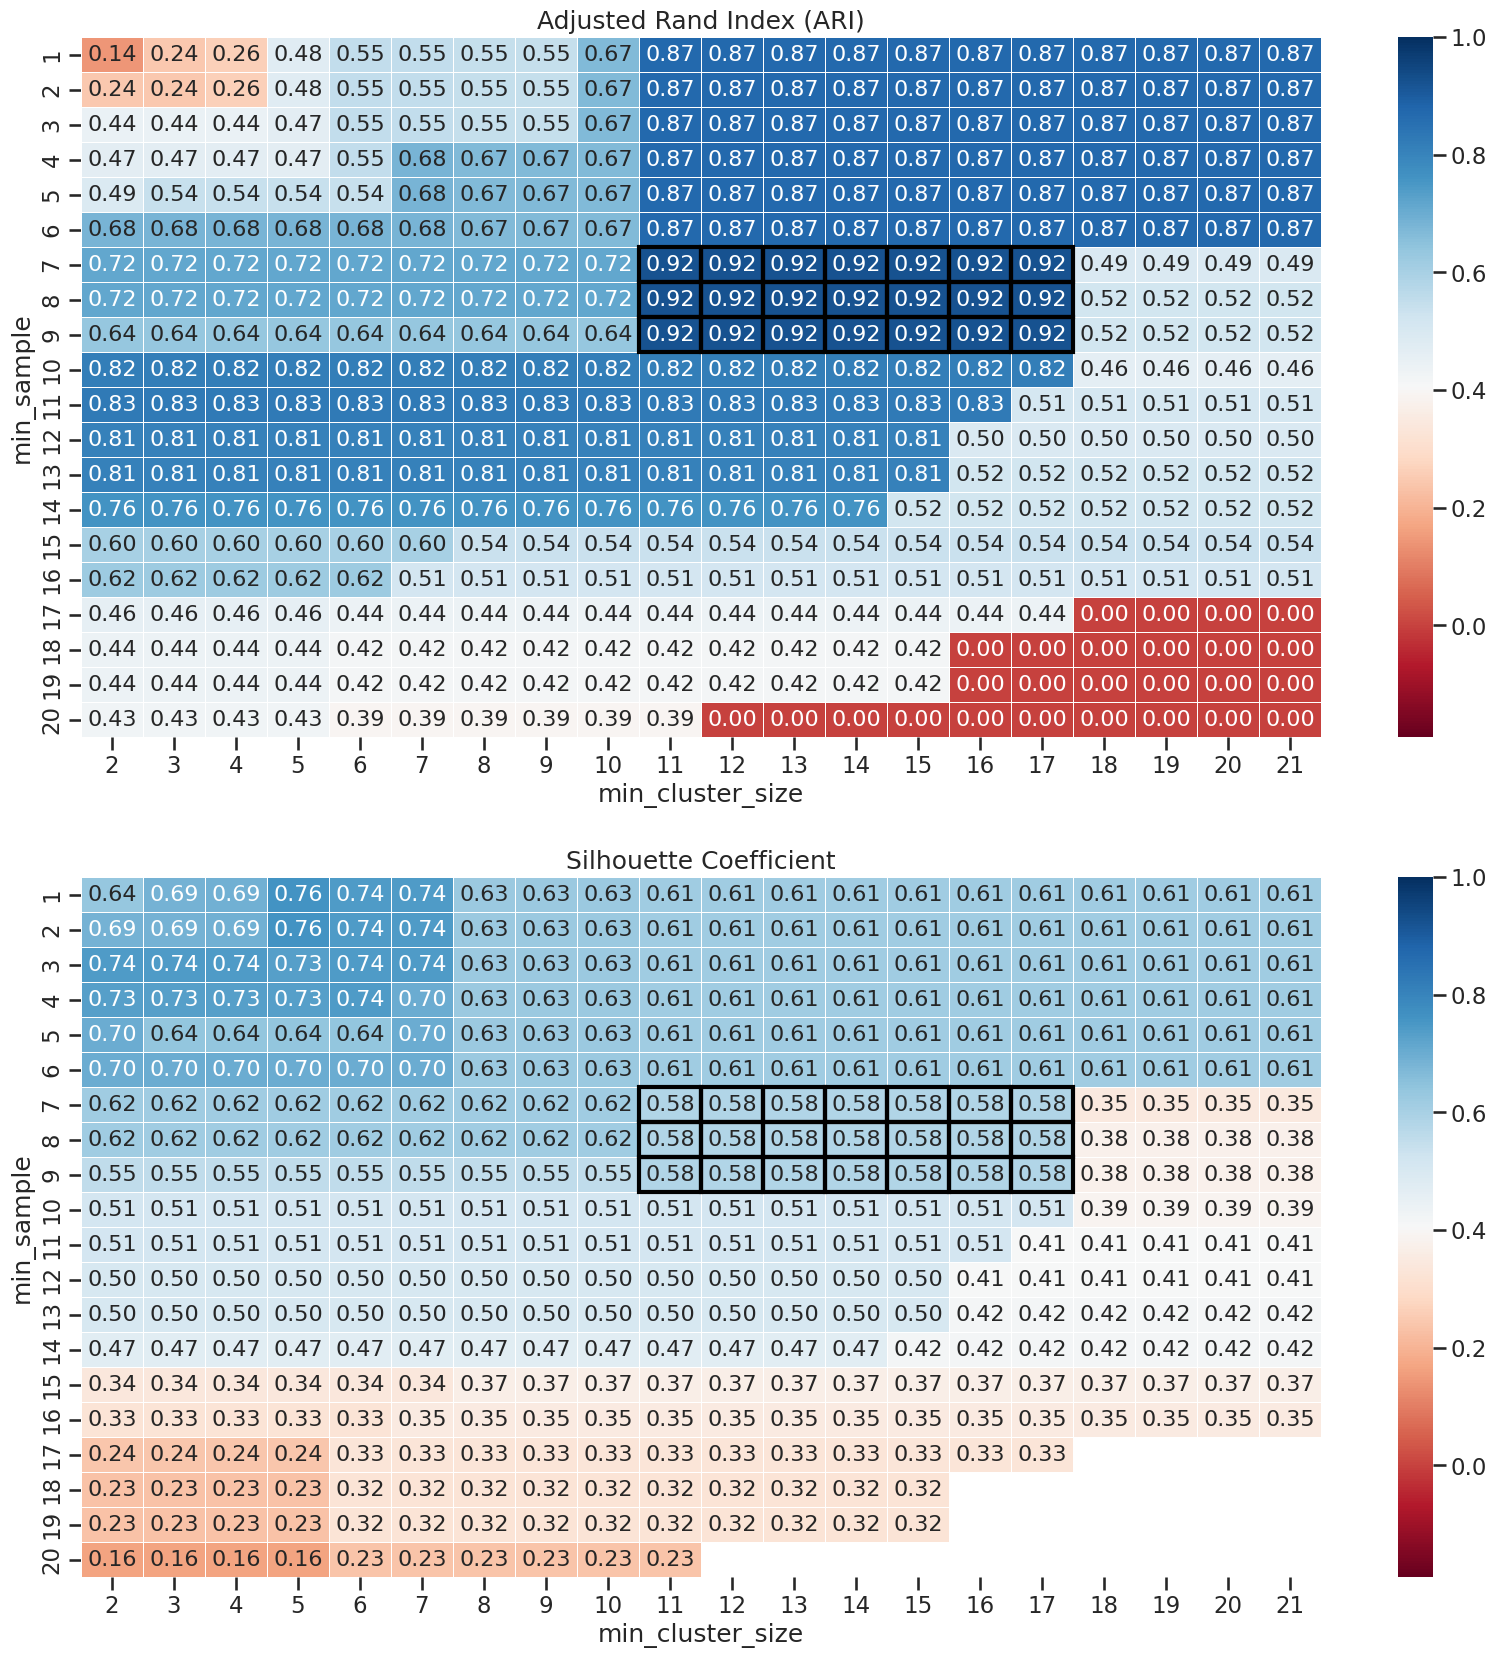

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def ari_sc_heatmap(parquet_file, min_samples_max, min_cluster_size_max):
    embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')
    embedding_matrix = embedded_df[['t-SNE component 1', 't-SNE component 2']].values

    results = []
    for ms in range(1, min_samples_max):
        for mcs in range(2, min_cluster_size_max):
            # Cluster
            clusterer = hdbscan.HDBSCAN(
                min_samples=ms,
                min_cluster_size=mcs,
                core_dist_n_jobs=-1
            ).fit(embedding_matrix)

            labels = clusterer.labels_

            # Evaluate clustering
            ari = adjusted_rand_score(embedded_df["Variant"], labels)

            # Check number of clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters > 1:
                silhouette_avg = silhouette_score(embedding_matrix, labels)
            else:
                silhouette_avg = np.nan  # or 0, depending on how you want to treat it

            # Store results
            results.append({
                "min_sample": ms,
                "min_cluster_size": mcs,
                "ari": ari,
                "silhouette": silhouette_avg
            })

            print(f"min_sample {ms}, min_cluster_size {mcs}: Adjusted Rand Index: {ari:.2f}, Silhouette Coefficient: {silhouette_avg:.2f}")

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Pivot matrices
    ari_matrix = df.pivot(index='min_sample', columns='min_cluster_size', values='ari')
    silhouette_matrix = df.pivot(index='min_sample', columns='min_cluster_size', values='silhouette')

    # Plot heatmaps
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axs = plt.subplots(2, 1, figsize=(20, 20))

    sns.heatmap(ari_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[0], vmin=-0.19, vmax=1)
    axs[0].set_title("Adjusted Rand Index (ARI)")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_sample")

    max_ari = ari_matrix.max().max()  # Get the max ARI value

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[0].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    sns.heatmap(silhouette_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[1], vmin=-0.19, vmax=1)
    axs[1].set_title("Silhouette Coefficient")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_sample")

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[1].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )
    save_as = parquet_file.replace(".parquet", ".HDBSCAN_heatmap")
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.show()

data_dir = "../../../data/betacov"
parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.from-esm-mlm.CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')
embedding_matrix = np.vstack(embedded_df["embedding"])

# Save the embedding based off best perplexity
perp = 3
tsne_reducer = TSNE(n_components=2, perplexity=perp, learning_rate='auto', random_state=42, n_jobs=8)
embedding_matrix_reduced = tsne_reducer.fit(embedding_matrix)

plot_df = pd.DataFrame({
    't-SNE component 1': embedding_matrix_reduced[:, 0],
    't-SNE component 2': embedding_matrix_reduced[:, 1],
    'Seq ID': embedded_df['seq_id'],
    'Variant': embedded_df['variant'],
    'Host': embedded_df['host']
})
save_as = f"BETACOV.from-esm-mlm.CLS-embedded.tSNE-perplexity{perp}.parquet"
plot_df.to_parquet(save_as, engine='fastparquet')

# Load the embedding
perp = 3
parquet_file = f"BETACOV.from-esm-mlm.CLS-embedded.tSNE-perplexity{perp}.parquet"
ari_sc_heatmap(parquet_file, min_samples_max=21, min_cluster_size_max=22)

Plotting the tSNE embeddings after applying HDBSCAN.

min_sample 7, min_cluster_size 11: Adjusted Rand Index: 0.92, Silhouette Coefficient: 0.58


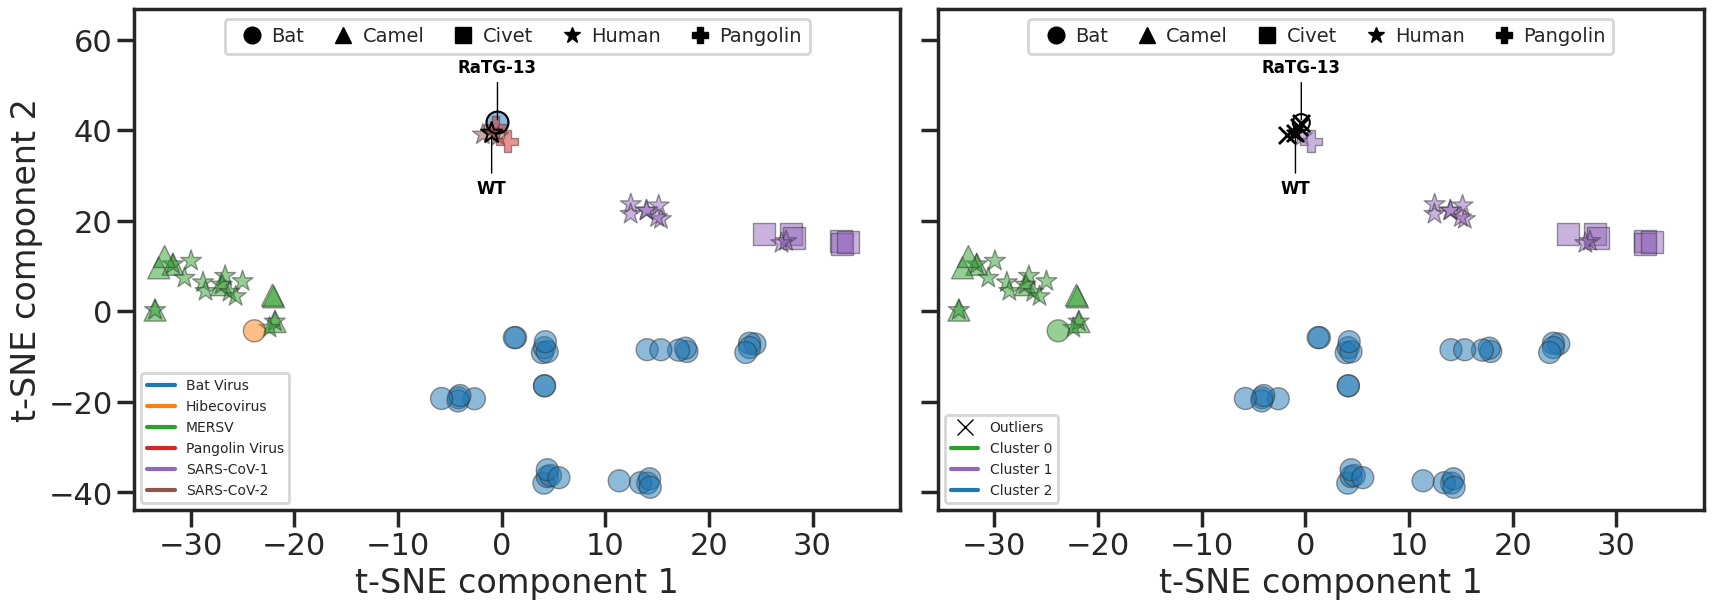

   t-SNE component 1  t-SNE component 2  Cluster    Seq ID    Variant Host
3          24.440416          -7.191122        2  KT444582  Bat Virus  Bat
5          23.924021          -7.034724        2  KF367457  Bat Virus  Bat
6          23.925508          -7.994940        2  KY417151  Bat Virus  Bat
9          23.562956          -9.088177        2  KF569996  Bat Virus  Bat


Predicted Clusters,-1,0,1,2
Ground Truth,,,,
Bat Virus,3.03,0.0,0.00,96.97
Hibecovirus,0.00,100.0,0.00,0.00
MERSV,0.00,100.0,0.00,0.00
Pangolin Virus,50.00,0.0,50.00,0.00
SARS-CoV-1,0.00,0.0,100.00,0.00
SARS-CoV-2,66.67,0.0,33.33,0.00


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')
    embedding_matrix = embedded_df[['t-SNE component 1', 't-SNE component 2']].values

    # Cluster
    hdb_labels = hdbscan.HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
        core_dist_n_jobs=-1  # Enable parallel processing
    ).fit(embedding_matrix).labels_

    # Evaluate clustering
    silhouette_avg = silhouette_score(embedding_matrix, hdb_labels)
    ari = adjusted_rand_score(embedded_df["Variant"], hdb_labels)
    print(f"min_sample {min_samples}, min_cluster_size {min_cluster_size}: Adjusted Rand Index: {ari:.2f}, Silhouette Coefficient: {silhouette_avg:.2f}")

    # Create the truth table
    truth_table_percent = pd.crosstab(embedded_df["Variant"], hdb_labels, 
                                    rownames=['Ground Truth'], 
                                    colnames=['Predicted Clusters'],
                                    normalize='index')  # Normalize along the index (rows)
    truth_table_percent = (truth_table_percent * 100).round(2)

    # Save
    plot_df = pd.DataFrame({
        't-SNE component 1': embedding_matrix[:, 0],
        't-SNE component 2': embedding_matrix[:, 1],
        'Cluster': hdb_labels,
        'Seq ID': embedded_df['Seq ID'],
        'Variant': embedded_df['Variant'],
        'Host': embedded_df['Host'],
    })    
    save_as = parquet_file.replace(".parquet", f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}")
    plot_df.to_parquet(f"{save_as}.parquet", engine='fastparquet')
    
    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, annotation_labels, x_min_width_buffer, x_max_width_buffer, y_min_width_buffer, y_max_width_buffer, color_map, cluster_color_palette_order):
    marker_size = 250

    # Define a host shape palette
    unique_hosts = np.unique(plot_df['Host'])
    host_marker_palette = ['o', '^', 's', '*', 'P', 'D', 'v', 'p', '.', '>', '<', 'd', 'H', 'h', '8']   # Use only filled markers
    host_marker_dict = {label: marker for label, marker in zip(unique_hosts, host_marker_palette)}
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df['Cluster'])
    cluster_color_palette = sns.color_palette(color_map, n_colors=10) 
    cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]
    cluster_color_dict = {label: color for label, color in zip(unique_clusters[unique_clusters != -1], cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x='t-SNE component 1', y='t-SNE component 2',
        hue='Variant', palette=variant_color_dict, 
        style='Host', markers=host_marker_dict,  
        s=marker_size, alpha=0.5, edgecolor=".2", linewidth=1,
        ax=axs[0]
    )

    # Outline points in black 
    annotate_df = plot_df[plot_df['Seq ID'].isin(annotation_labels)]
    sns.scatterplot(
        data=annotate_df,
        x='t-SNE component 1', y='t-SNE component 2',
        style='Host', markers=host_marker_dict,  
        s=marker_size, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[0]
    )

    # Annotate points
    for idx, row in annotate_df.iterrows():
        if row['Seq ID'] in annotation_labels:  # Only annotate specified labels
            x, y = row['t-SNE component 1'], row['t-SNE component 2']
            if row['Seq ID'] == 'MN908947': label = "WT"
            elif row['Seq ID'] == 'MN996532': label = "RaTG-13"
            else: label = row['Seq ID']
            x_offset, y_offset = annotation_labels.get(row['Seq ID']) 
                        
            axs[0].annotate(
                label, 
                (x, y), xytext=(x_offset, y_offset), textcoords='offset points',
                color='k',
                fontsize=12, fontweight='bold', ha='center', va='center',
                arrowprops=dict(arrowstyle="-", color='k', lw=1)
            )

    axs[0].set_xlim((plot_df['t-SNE component 1'].min()-x_min_width_buffer, plot_df['t-SNE component 1'].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df['t-SNE component 2'].min()-y_min_width_buffer, plot_df['t-SNE component 2'].max()+y_max_width_buffer),

    # Legend 
    host_handles = [
        plt.Line2D([0], [0], marker=host_marker_dict[host], color='black', linestyle='none', label=f'{host}')
        for host in unique_hosts
    ]
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    # axs[0].legend(handles=variant_handles+host_handles)
    host_legend = axs[0].legend(handles=host_handles, ncol=5, columnspacing=1, handletextpad=0, loc="upper center", fontsize=14)
    variant_legend = axs[0].legend(handles=variant_handles, ncol=1, loc="lower left", fontsize=10)
    axs[0].add_artist(host_legend)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x='t-SNE component 1', y='t-SNE component 2',
        hue='Cluster', palette=cluster_color_dict, 
        style='Host', markers=host_marker_dict,
        s=marker_size, alpha=0.5, edgecolor=".2", linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x='t-SNE component 1', y='t-SNE component 2',
        marker='x',
        s=marker_size-100, color='black', linewidth=2,
        ax=axs[1]
    )

    # Outline points in black 
    annotate_df = plot_df[plot_df['Seq ID'].isin(annotation_labels)]
    sns.scatterplot(
        data=annotate_df[annotate_df['Cluster'] != -1],
        x='t-SNE component 1', y='t-SNE component 2',
        style='Host', markers=host_marker_dict,  
        s=marker_size, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[1]
    )

    sns.scatterplot(
        data=annotate_df[annotate_df['Cluster'] == -1],
        x='t-SNE component 1', y='t-SNE component 2',
        style='Host', markers=host_marker_dict,  
        s=marker_size-100, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[1]
    )

    # Annotate points
    for idx, row in annotate_df.iterrows():
        if row['Seq ID'] in annotation_labels:  # Only annotate specified labels
            x, y = row['t-SNE component 1'], row['t-SNE component 2']
            if row['Seq ID'] == 'MN908947': label = "WT"
            elif row['Seq ID'] == 'MN996532': label = "RaTG-13"
            else: label = row['Seq ID']
            x_offset, y_offset = annotation_labels.get(row['Seq ID']) 
                        
            axs[1].annotate(
                label, 
                (x, y), xytext=(x_offset, y_offset), textcoords='offset points',
                color='k',
                fontsize=12, fontweight='bold', ha='center', va='center',
                arrowprops=dict(arrowstyle="-", color='k', lw=1)
            )

    axs[1].set_xlim((plot_df['t-SNE component 1'].min()-x_min_width_buffer, plot_df['t-SNE component 1'].max()+x_max_width_buffer))

    # Legend 
    host_handles = [
        plt.Line2D([0], [0], marker=host_marker_dict[host], color='black', linestyle='none', label=f'{host}')
        for host in unique_hosts
    ]
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    host_legend = axs[1].legend(handles=host_handles, ncol=5, columnspacing=1, handletextpad=0, loc="upper center", fontsize=14)
    cluster_legend = axs[1].legend(handles=cluster_handles, ncol=1, loc="lower left", fontsize=10)
    axs[1].add_artist(host_legend)

    #####################################################
  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=600, bbox_inches='tight')
    plt.show()

    print(plot_df[plot_df['Seq ID'].isin(["KF569996", "KT444582", "KF367457", "KY417151"])])

seed = 0
perp = 3
parquet_file = f"BETACOV.from-esm-mlm.CLS-embedded.tSNE-perplexity{perp}.parquet"

min_samples=7
min_cluster_size=11
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

# Call the function
annotation_labels = {
    'MN908947':(0,-40),
    'MN996532':(0,40),
    # 'KF569996':(-75,0),
    # 'KT444582':(-10,-40),
    # 'KF367457':(-5,100),
    # 'KY417151':(-50,55)
}
plot_groundtruth_prediction_1x2(
    plot_df, save_as, annotation_labels, 
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=25, 
    color_map="tab10",cluster_color_palette_order=[2,4,0,3,1,5,6,7,8,9]
)
truth_table_percent

In [10]:
phylo_df = plot_df.drop(columns=["t-SNE component 1", "t-SNE component 2"])
phylo_df.to_csv("betacov_clustering-from-esm-mlm.csv", index=False)

---
### Without the from_esm_mlm set:

In [30]:
seed = 0
L.seed_everything(seed)  # Set seed for reproducibility
data_dir = "../../../data/betacov"

# Trainer setup 
trainer= L.Trainer(
    limit_test_batches=1.0, # 1.0 is 100% of batches 
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    num_nodes=1,
    devices=1,
    logger=False,
    enable_progress_bar=True
)

# Initialize DataModule and model
dm = BetaCovDataModule(
    data_dir = data_dir,
    batch_size = 64,
    num_workers = 4, 
    seed = seed
)
dm.setup("test")

model = LightningProteinEsmEmbedder(
    max_len = dm.test_dataset.max_len + 2, # Account for CLS, EOS tokens
    csv_file = os.path.join(data_dir, "betacoronavirus_seq.csv"),
    esm_version = "facebook/esm2_t6_8M_UR50D",
)

start_time = time.perf_counter()
trainer.test(model, dm)  # Test model
duration = datetime.timedelta(seconds=time.perf_counter()-start_time)
print(f"[Timing] Test.fit(...) took: {duration} (hh:mm:ss).")

Seed set to 0
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_test_batches=1.0)` was configured so 100% of the batches will be used..
Seed set to 0
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  5.72it/s]
[Timing] Test.fit(...) took: 0:00:00.691356 (hh:mm:ss).


In [31]:
# Load in the data
data_dir = "../../../data/betacov"
parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.CLS-embedded.parquet")

best_perplexity(parquet_file, perp_list=range(1, (75//3)+1), min_samples_max=26, min_cluster_size_max=26)

[Perplexity=1] Max ARI: 0.3152, assoc. SC: 0.7010 @ min_sample=3, min_cluster_size=2
[Perplexity=2] Max ARI: 0.5835, assoc. SC: 0.3148 @ min_sample=13, min_cluster_size=8
[Perplexity=3] Max ARI: 0.5571, assoc. SC: 0.5711 @ min_sample=1, min_cluster_size=10
[Perplexity=4] Max ARI: 0.5571, assoc. SC: 0.6816 @ min_sample=1, min_cluster_size=10
[Perplexity=5] Max ARI: 0.5571, assoc. SC: 0.7167 @ min_sample=1, min_cluster_size=10
[Perplexity=6] Max ARI: 0.7157, assoc. SC: 0.7488 @ min_sample=2, min_cluster_size=8
[Perplexity=7] Max ARI: 0.7238, assoc. SC: 0.6885 @ min_sample=6, min_cluster_size=3
[Perplexity=8] Max ARI: 0.6683, assoc. SC: 0.7487 @ min_sample=1, min_cluster_size=8
[Perplexity=9] Max ARI: 0.6916, assoc. SC: 0.6665 @ min_sample=5, min_cluster_size=5
[Perplexity=10] Max ARI: 0.6683, assoc. SC: 0.7516 @ min_sample=1, min_cluster_size=8
[Perplexity=11] Max ARI: 0.6683, assoc. SC: 0.7653 @ min_sample=1, min_cluster_size=8
[Perplexity=12] Max ARI: 0.6966, assoc. SC: 0.6875 @ min_sa

Perplexity value 25 is too high. Using perplexity 24.67 instead


[Perplexity=24] Max ARI: 0.6688, assoc. SC: 0.7406 @ min_sample=5, min_cluster_size=6
[Perplexity=25] Max ARI: 0.5571, assoc. SC: 0.8368 @ min_sample=1, min_cluster_size=8


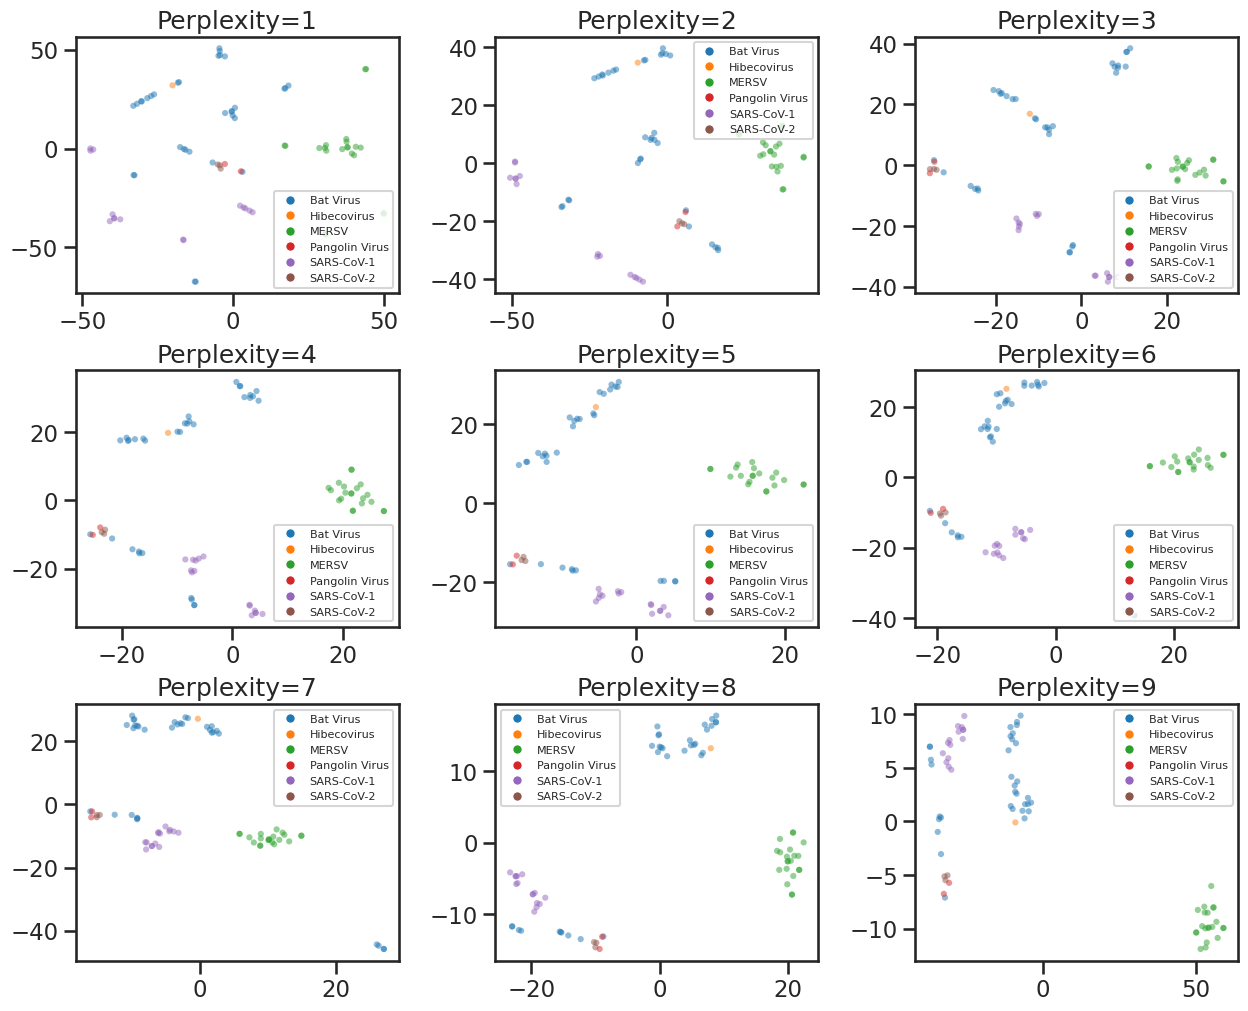

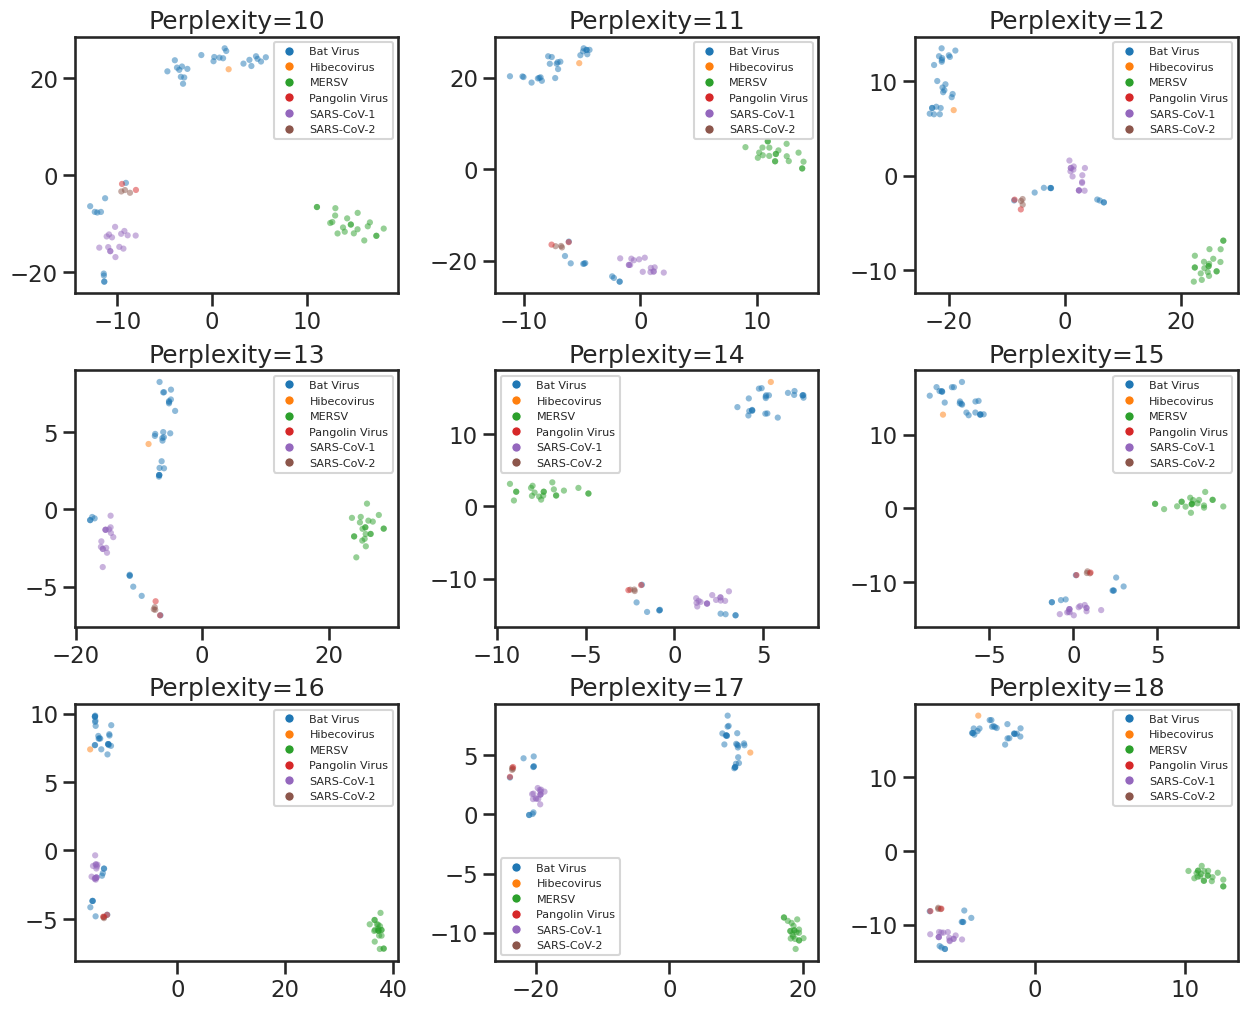

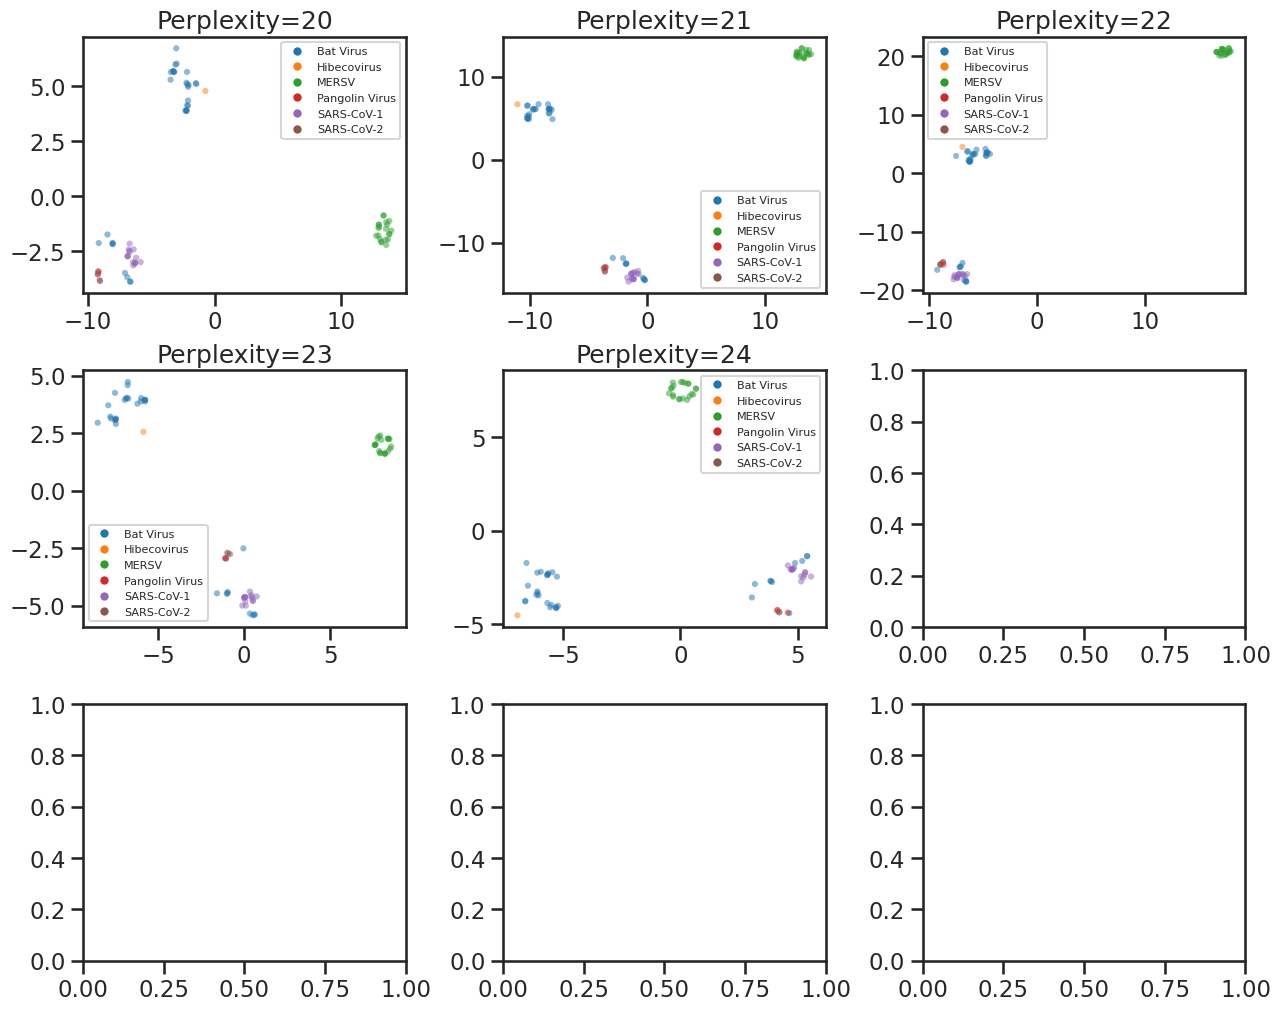

In [65]:
data_dir = "../../../data/betacov"
plot_perplexities(
    parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.CLS-embedded.parquet"),
    perp_list = range(1,10)
)
plot_perplexities(
    parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.CLS-embedded.parquet"),
    perp_list = range(10,20)
)
plot_perplexities(
    parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.CLS-embedded.parquet"),
    perp_list = range(20, 25)
)

min_sample 1, min_cluster_size 2: Adjusted Rand Index: 0.14, Silhouette Coefficient: 0.48
min_sample 1, min_cluster_size 3: Adjusted Rand Index: 0.23, Silhouette Coefficient: 0.53
min_sample 1, min_cluster_size 4: Adjusted Rand Index: 0.48, Silhouette Coefficient: 0.72
min_sample 1, min_cluster_size 5: Adjusted Rand Index: 0.47, Silhouette Coefficient: 0.70
min_sample 1, min_cluster_size 6: Adjusted Rand Index: 0.47, Silhouette Coefficient: 0.70
min_sample 1, min_cluster_size 7: Adjusted Rand Index: 0.47, Silhouette Coefficient: 0.70
min_sample 1, min_cluster_size 8: Adjusted Rand Index: 0.59, Silhouette Coefficient: 0.70
min_sample 1, min_cluster_size 9: Adjusted Rand Index: 0.72, Silhouette Coefficient: 0.75
min_sample 1, min_cluster_size 10: Adjusted Rand Index: 0.72, Silhouette Coefficient: 0.75
min_sample 1, min_cluster_size 11: Adjusted Rand Index: 0.72, Silhouette Coefficient: 0.75
min_sample 1, min_cluster_size 12: Adjusted Rand Index: 0.59, Silhouette Coefficient: 0.76
min_sam

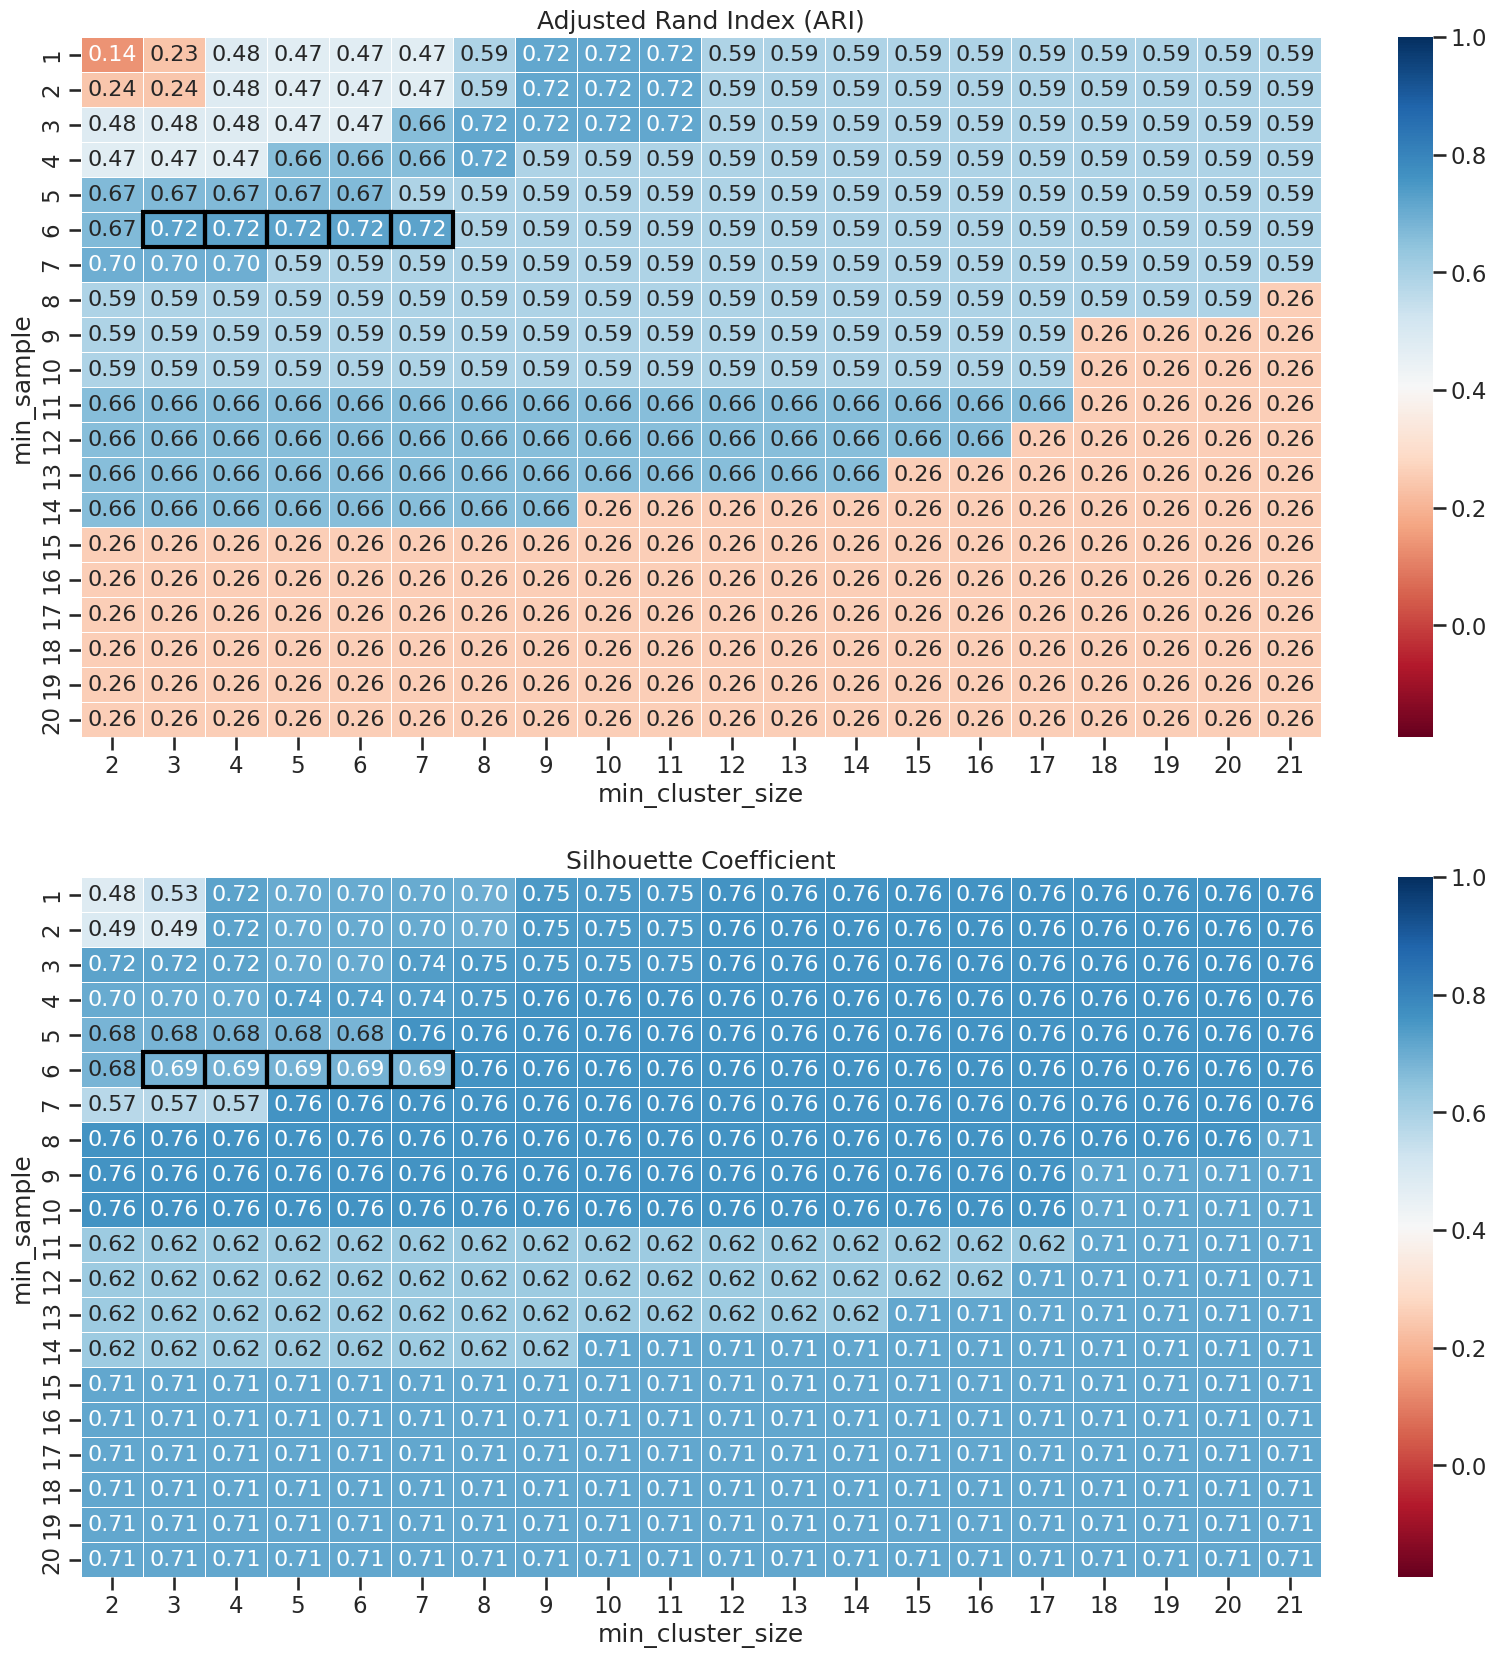

In [5]:
data_dir = "../../../data/betacov"
parquet_file = os.path.join(data_dir, f"betacoronavirus_seq.CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')
embedding_matrix = np.vstack(embedded_df["embedding"])

# Save the embedding based off best perplexity
perp = 7
tsne_reducer = TSNE(n_components=2, perplexity=perp, learning_rate='auto', random_state=42, n_jobs=8)
embedding_matrix_reduced = tsne_reducer.fit(embedding_matrix)

plot_df = pd.DataFrame({
    't-SNE component 1': embedding_matrix_reduced[:, 0],
    't-SNE component 2': embedding_matrix_reduced[:, 1],
    'Seq ID': embedded_df['seq_id'],
    'Variant': embedded_df['variant'],
    'Host': embedded_df['host']
})
save_as = f"BETACOV.CLS-embedded.tSNE-perplexity{perp}.parquet"
plot_df.to_parquet(save_as, engine='fastparquet')

# Load the embedding
perp = 7
parquet_file = f"BETACOV.CLS-embedded.tSNE-perplexity{perp}.parquet"
ari_sc_heatmap(parquet_file, min_samples_max=21, min_cluster_size_max=22)

min_sample 6, min_cluster_size 3: Adjusted Rand Index: 0.72, Silhouette Coefficient: 0.69


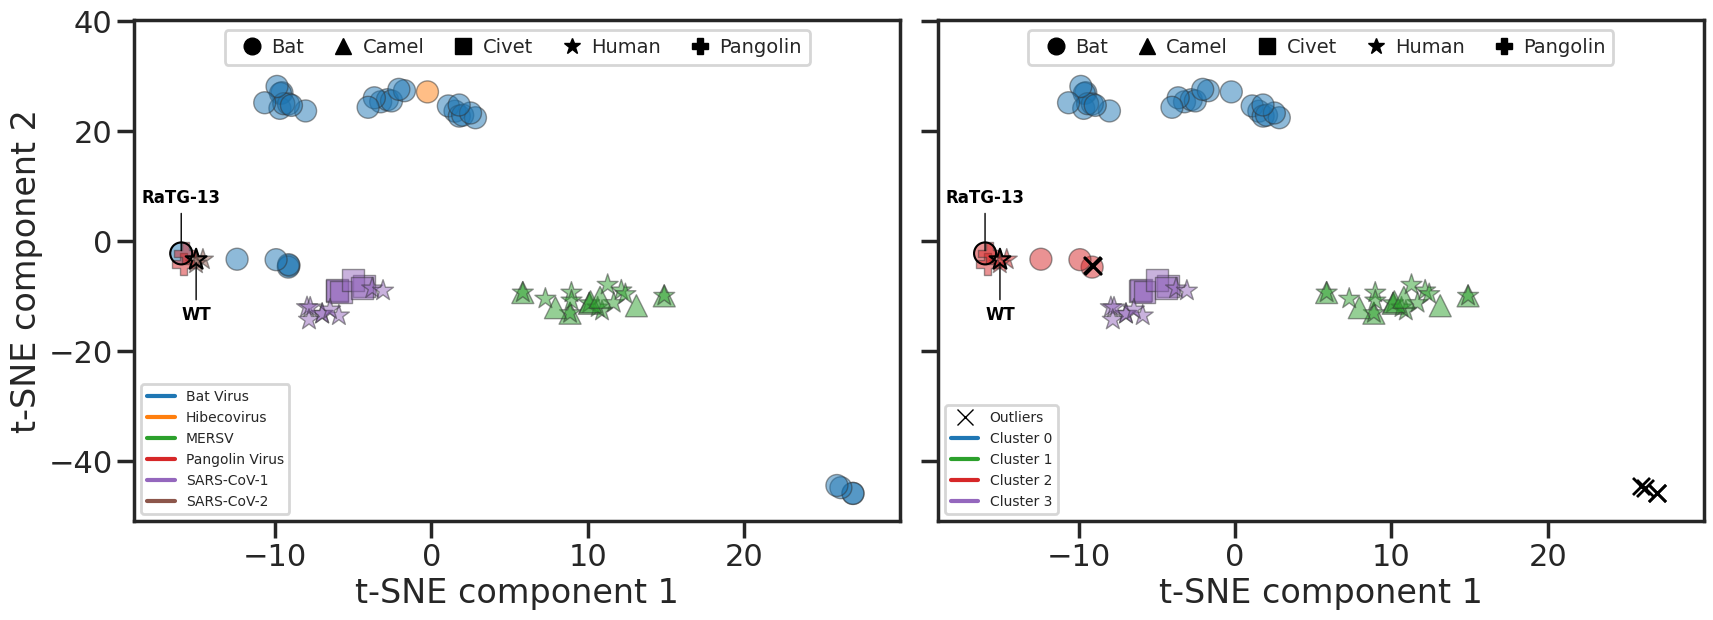

   t-SNE component 1  t-SNE component 2  Cluster    Seq ID    Variant Host
3          26.981716         -45.836935       -1  KT444582  Bat Virus  Bat
5          26.981716         -45.836934       -1  KF367457  Bat Virus  Bat
6          26.207222         -44.793956       -1  KY417151  Bat Virus  Bat
9          25.952185         -44.400042       -1  KF569996  Bat Virus  Bat


Predicted Clusters,-1,0,1,2,3
Ground Truth,,,,,
Bat Virus,18.18,69.7,0.0,12.12,0.0
Hibecovirus,0.00,100.0,0.0,0.00,0.0
MERSV,0.00,0.0,100.0,0.00,0.0
Pangolin Virus,0.00,0.0,0.0,100.00,0.0
SARS-CoV-1,0.00,0.0,0.0,0.00,100.0
SARS-CoV-2,0.00,0.0,0.0,100.00,0.0


In [11]:
seed = 0
perp = 7
parquet_file = f"BETACOV.CLS-embedded.tSNE-perplexity{perp}.parquet"

min_samples=6
min_cluster_size=3
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

# Call the function
annotation_labels = {
    'MN908947':(0,-40),
    'MN996532':(0,40),
    # 'KF569996':(-75,0),
    # 'KT444582':(-10,-40),
    # 'KF367457':(-5,100),
    # 'KY417151':(-50,55)
}
plot_groundtruth_prediction_1x2(
    plot_df, save_as, annotation_labels, 
    x_min_width_buffer=3, x_max_width_buffer=3, y_min_width_buffer=5, y_max_width_buffer=12, 
    color_map="tab10",cluster_color_palette_order=[0,2,3,4,5,1,6,7,8,9]
)
truth_table_percent

In [12]:
phylo_df = plot_df.drop(columns=["t-SNE component 1", "t-SNE component 2"])
phylo_df.to_csv("betacov_clustering.csv", index=False)